In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
import numpy as np 
import seaborn as sbn 
import pickle as pkl
from matplotlib import cm
import torch 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import percentileofscore
from shutil import rmtree
import argparse

import sys 
sys.path.append('../src/')
from utils import get_filtered_scores, train_model
from AE import AE
from NN import NN
from DVGS import DVGS
import similarities

sys.path.append('../scripts/')
from run_beataml import *



/home/teddy/miniconda3/envs/dvgs/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
args = argparse.Namespace()
args.data = '../../beatAML/'
args.drug = 'Imatinib'
args.source_p = 0.7
args.variance_filter = 1000
args.zscore = True
args.pca = False
args.num_pca_comp = 25
args.supervised = True

X,y,ids = load_data_supervised(args=args)

In [3]:
X_target, X_source, y_target, y_source, target_ids, source_ids = train_test_split(X, y, ids, test_size=args.source_p)

# TODO: should we be normalizing based on target or source??? Currently using target. I think that makes sense. 
X_target, X_source, y_target, y_source = normalize(X_train=X_target, X_test=X_source, y_train=y_target, y_test=y_source, args=args)

X_target = torch.tensor(X_target, dtype=torch.float32)
X_source = torch.tensor(X_source, dtype=torch.float32)
y_source = torch.tensor(y_source, dtype=torch.float32).view(-1, 1)
y_target = torch.tensor(y_target, dtype=torch.float32).view(-1, 1)

In [4]:
nn_kwargs = lambda: {
                "out_channels"      : 1, 
                "hidden_channels"   : 10, 
                "num_layers"        : 1, 
                "norm"              : True, 
                "dropout"           : 0.1, 
                "bias"              : True, 
                "act"               : torch.nn.ELU
                }

model = NN(in_channels=X_target.size(1), **nn_kwargs())

#model = LM(in_channels=X_target.size(1), out_channels=1)

model, res = train_model(model           = model,
                            crit            = torch.nn.MSELoss(), 
                            metric          = lambda x,y: np.corrcoef(x.ravel(),y.ravel())[0,1],
                            x_train         = X_source, 
                            y_train         = y_source, 
                            x_test          = X_target, 
                            y_test          = y_target, 
                            batch_size      = 50,
                            lr              = 1e-3,
                            epochs          = 100, 
                            verbose = True)


using device: cuda


In [5]:
res

0.16109405856913564

In [6]:
yhat_target = model(X_target.cuda())

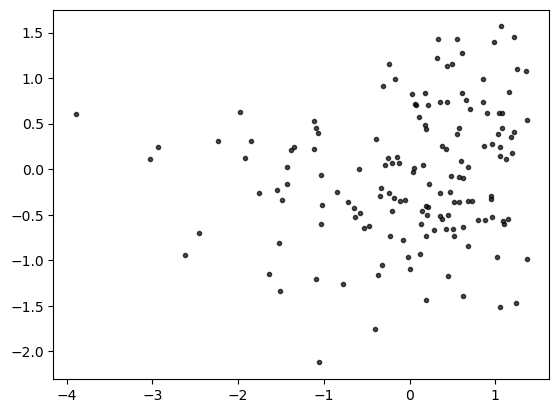

In [7]:
plt.figure()
plt.plot(y_target.detach().cpu().numpy(), yhat_target.detach().cpu().numpy(), 'k.', alpha=0.7)

In [41]:
expr = pd.read_csv('../../beatAML/beataml_waves1to4_norm_exp_dbgap.txt', sep='\t')
expr.head(3)

,stable_id,display_label,description,biotype,BA2392R,BA2611R,BA2506R,BA2430R,BA2448R,BA2730R,...,BA3376R,BA3137R,BA3300R,BA3375R,BA3249R,BA3385R,BA3242R,BA3446R,BA3416R,BA3123R
0,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:11858],protein_coding,1.523670,1.856566,1.701307,1.870627,1.699496,1.938355,...,-0.912409,-3.152332,-3.449852,-1.356856,-1.313394,-1.942942,-3.531597,-1.833196,-2.026912,-2.760852
1,ENSG00000000419,DPM1,dolichyl-phosphate mannosyltransferase polypep...,protein_coding,7.107711,6.865282,6.889932,6.969120,6.884921,6.902968,...,7.020525,6.977313,7.104581,7.054989,6.303723,6.973836,6.909407,7.105341,7.160451,6.776057
2,ENSG00000000457,SCYL3,SCY1-like 3 (S. cerevisiae) [Source:HGNC Symbo...,protein_coding,3.362605,3.320940,3.407834,3.265446,3.428475,3.325013,...,4.015234,3.569042,3.893597,3.781837,4.712288,4.107911,3.963806,4.160099,4.002085,3.705729


In [42]:
ids = expr.columns[4:].tolist()
ids[:3]

['BA2392R', 'BA2611R', 'BA2506R']

In [43]:
info = pd.read_excel('../../beatAML/beataml_wv1to4_clinical.xlsx')[lambda x: x.dbgap_rnaseq_sample.isin(ids)]
info.head()

,dbgap_subject_id,dbgap_dnaseq_sample,dbgap_rnaseq_sample,cohort,used_manuscript_analyses,manuscript_dnaseq,manuscript_rnaseq,manuscript_inhibitor,consensus_sex,inferred_sex,...,surfaceAntigensImmunohistochemicalStains,totalProtein,wbcCount,FLT3-ITD,allelic_ratio,NPM1,RUNX1,ASXL1,TP53,variantSummary
5,2157,BA2452D,BA2452R,Both,no,no,no,no,Male,Male,...,"partial CD7, CD13, CD33, CD38, dim CD45, dimCD...",5.8,0.6,positive,0.960784,positive,NaN,NaN,NaN,NaN
8,2269,NaN,BA2922R,Waves1+2,yes,no,yes,yes,Male,Male,...,"CD13, CD33, CD34, CD38, CD117,CD123, dim HLA-D...",7.6,2.2,positive,NaN,NaN,NaN,NaN,NaN,FLT3-ITD
22,2313,BA2707D,BA2707R,Both,no,no,no,no,Male,Male,...,"partial CD7, CD11b, CD13, CD33, CD34, partial ...",NaN,47.2,negative,0.000000,negative,RUNX1 (p.A147Gfs*13; 42.3%)|RUNX1 (p.R162S; 46...,ASXL1 (p.G646Wfs*12; 27.9%),NaN,RUNX1 (p.A147fs*13 (1 bp insertion frameshift)...
29,2418,NaN,BA2409R,Waves1+2,yes,no,yes,yes,Female,Female,...,"Blast Immunphenotype: CD13, CD33, CD34, CD38, ...",5.5,14.9,negative,0.000000,negative,NaN,NaN,NaN,BRAF (G596R)|WT1 (2400/10000 copies)
31,2374,NaN,BA2480R,Waves1+2,yes,no,yes,no,Male,Male,...,"CD13, CD33, partial CD56, CD58, CD64, dim CD11...",NaN,7.9,positive,2.448276,positive,NaN,NaN,NaN,NaN


In [44]:
info.groupby('specimenType').count()[['cohort']]

,cohort
specimenType,
Bone Marrow Aspirate,362
Leukapheresis,16
Peripheral Blood,293


In [45]:
expr.shape

(22843, 711)

In [46]:
X = expr.values[:, 4:].T.astype(float)

In [47]:
X.dtype

dtype('float64')

In [48]:
np.isnan(X).mean()

0.0

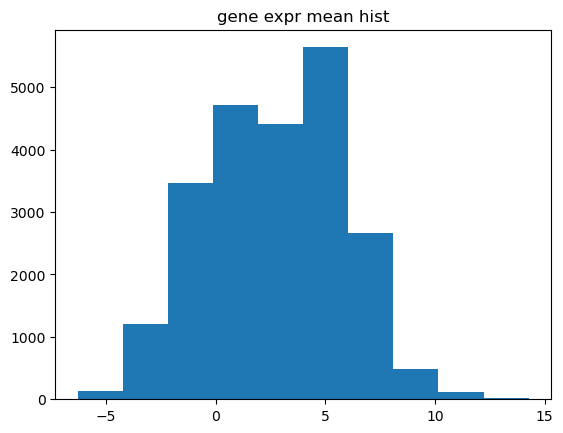

In [49]:
plt.figure()
plt.title('gene expr mean hist')
plt.hist(X.mean(axis=0))
plt.show()

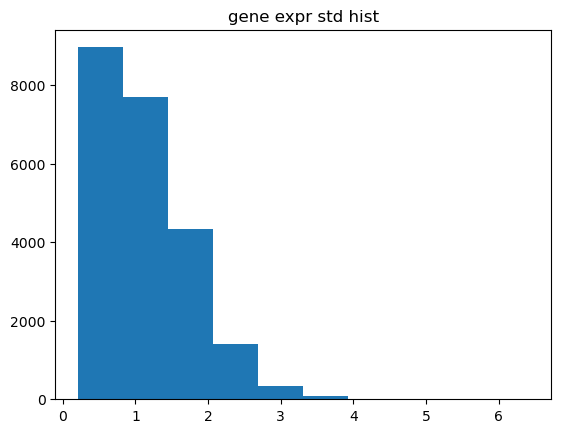

In [50]:
plt.figure()
plt.title('gene expr std hist')
plt.hist(X.std(axis=0))
plt.show()

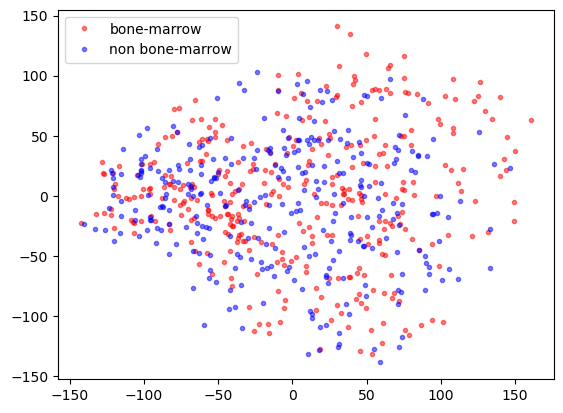

In [51]:
#bone marrow (bm)
bm_samples = info[lambda x: x.specimenType == 'Bone Marrow Aspirate'].dbgap_rnaseq_sample.unique()
bm_x_idx = np.isin(ids, bm_samples).nonzero()[0]
X_bm = X[bm_x_idx, :]
len(bm_samples)

# non bm (nbm)
nbm_samples = info[lambda x: x.specimenType != 'Bone Marrow Aspirate'].dbgap_rnaseq_sample.unique()
nbm_x_idx = np.isin(ids, nbm_samples).nonzero()[0]
X_nbm = X[nbm_x_idx, :]
len(nbm_samples)

reducer = PCA(2)
pc = reducer.fit_transform(X)

plt.figure()
plt.plot(*pc[bm_x_idx].T, 'r.', alpha=0.5, label='bone-marrow')
plt.plot(*pc[nbm_x_idx].T, 'b.', alpha=0.5, label='non bone-marrow')

plt.legend()
plt.show()

In [ ]:
# wgcna 

In [13]:
if True:
    # for EDA select high var samples 
    gene_idxs = (X.std(axis=0) > 2).nonzero()[0]
    X = X[:, gene_idxs]

if True:
    # zscore 
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

X.shape

(707, 2159)

In [339]:
split_design = 'random' 

# split bm samples into target, source, test 
# NOTE: behaves slightly differently with split design - see code 
target_p = 0.2
test_p = 0.1 
source_p = 0.7 


if split_design == 'random': 

    X_target, X_other, target_ids, other_ids = train_test_split(X, ids, test_size=(1-target_p))
    X_test, X_source, test_ids, source_ids = train_test_split(X_other, other_ids, test_size=source_p/(test_p + source_p))

    X_source = torch.tensor(X_source, dtype=torch.float32)
    X_target = torch.tensor(X_target, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)

elif split_design == 'bone_marrow': 

    #bone marrow (bm)
    bm_samples = info[lambda x: x.specimenType == 'Bone Marrow Aspirate'].dbgap_rnaseq_sample.unique()
    bm_x_idx = np.isin(ids, bm_samples).nonzero()[0]
    X_bm = X[bm_x_idx, :]
    len(bm_samples)

    # non bm (nbm)
    nbm_samples = info[lambda x: x.specimenType != 'Bone Marrow Aspirate'].dbgap_rnaseq_sample.unique()
    nbm_x_idx = np.isin(ids, nbm_samples).nonzero()[0]
    X_nbm = X[nbm_x_idx, :]
    len(nbm_samples)

    X_target, X_other, target_ids, other_ids = train_test_split(X_bm, bm_samples, test_size=(1-target_p))
    X_test, X_source, test_ids, source_ids = train_test_split(X_other, other_ids, test_size=source_p/(test_p + source_p))

    X_source = np.concatenate((X_source, X_nbm))
    source_ids = np.concatenate((source_ids, nbm_samples))

    X_source = torch.tensor(X_source, dtype=torch.float32)
    X_target = torch.tensor(X_target, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)

else: 
    raise NotImplementedError


print('# target samples', len(target_ids))
print('# source samples', len(source_ids))
print('# test samples', len(test_ids))

# target samples 98
# source samples 347
# test samples 49


In [340]:
model = AE(in_channels=X.shape[1], hidden_channels=100, latent_channels=50, num_layers=1, norm=False, dropout=0., bias=True, act=torch.nn.Mish)
nparams = sum([p.numel() for p in model.parameters()])
print('# params:', nparams)

dvgs = DVGS(x_source         = X_source,
            y_source         = X_source, 
            x_target         = X_target,  
            y_target         = X_target, 
            model            = model)

# params: 220094


In [341]:
dvgs_kwargs = { 
                "target_crit"           : torch.nn.MSELoss(), 
                "source_crit"           : torch.nn.MSELoss(),
                "num_restarts"          : 3,
                "save_dir"              : f'../results/BEATAML/dvgs/',
                "similarity"            : similarities.cosine_similarity(),
                "optim"                 : torch.optim.Adam, 
                "lr"                    : 1e-3, 
                "num_epochs"            : 100, 
                "compute_every"         : 1, 
                "source_batch_size"     : 100, 
                "target_batch_size"     : 50,
                "grad_params"           : None, 
                "verbose"               : True, 
                "use_cuda"              : True,
                "wd"                    : 1e-6
            }

uid = '_TEST_'

rmtree('../results/BEATAML/dvgs//_TEST_')

run_id = dvgs.run(**dvgs_kwargs, uid=uid)

using device: cuda
			 [restart: 0] iteration 99 || avg target loss: 0.15 || gradient sim. calc. elapsed / sample: 83.3 uss
			 [restart: 1] iteration 99 || avg target loss: 0.15 || gradient sim. calc. elapsed / sample: 80.0 us
			 [restart: 2] iteration 99 || avg target loss: 0.15 || gradient sim. calc. elapsed / sample: 80.2 us


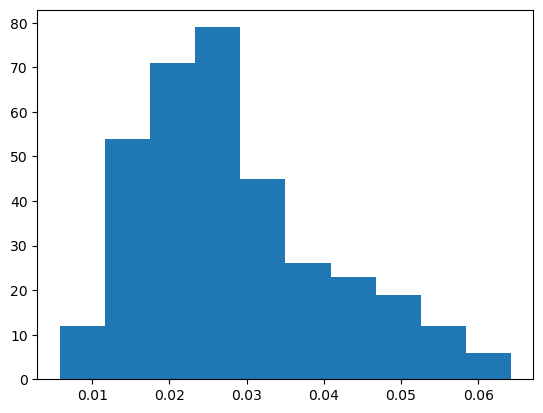

In [342]:
vals = dvgs.agg(f'../results/BEATAML/dvgs/{run_id}/').ravel()

plt.figure()
plt.hist(vals)
plt.show()

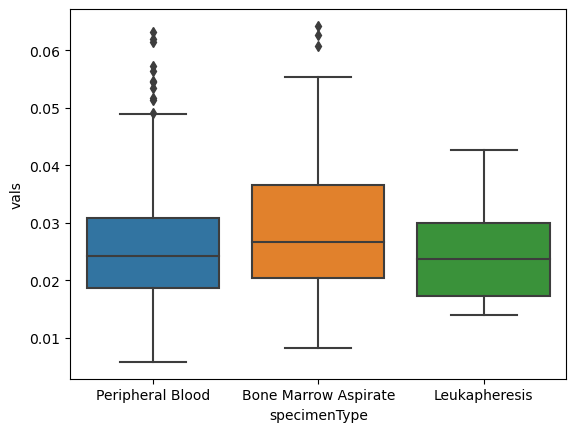

In [343]:
res = pd.DataFrame({'vals':vals, 'id':source_ids}).merge(info[['specimenType', 'dbgap_rnaseq_sample']], left_on='id', right_on='dbgap_rnaseq_sample', how='left')

plt.figure()
sbn.boxplot(x='specimenType', y='vals', data=res)
plt.show()

In [347]:
filter_kwargs = {
                "model"         : model, 
                "crit"          : torch.nn.MSELoss(),
                "metric"        : lambda x,y: r2_score(x,y, multioutput='variance_weighted'), #lambda x,y: np.mean((x - y)**2)**0.5 , # lambda x,y: r2_score(x,y, multioutput='variance_weighted')
                "qs"            : np.linspace(0., 0.5, 6), 
                "batch_size"    : 50,
                "lr"            : 1e-3, 
                "epochs"        : 100, 
                "repl"          : 2,
                "reset_params"  : True,
                'return_all_scores' : True
            }

perf_filter_low, perf_filter_high = get_filtered_scores(x_train       = X_source,
                                                        y_train       = X_source,
                                                        x_test        = X_test,
                                                        y_test        = X_test, 
                                                        vals          = vals, **filter_kwargs)

training filtered models... progress: 5/6


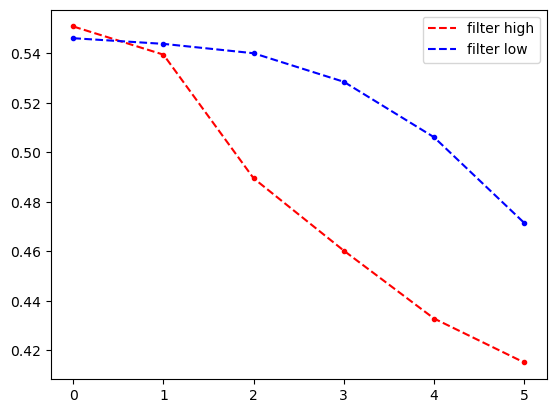

In [346]:
plt.figure()
plt.plot([np.mean(x) for x in perf_filter_high], 'r--', label='filter high')
plt.plot([np.mean(x) for x in perf_filter_low], 'b--', label='filter low')
#plt.ylim(-1,1)

for i, (h,l) in enumerate(zip(perf_filter_high, perf_filter_low)): 
    plt.plot([i]*len(h), h, 'r.')
    plt.plot([i]*len(l), l, 'b.')

plt.legend()
plt.show()

# Supervised learning 

Choose hard to predict drugs potentially 
or drugs with known data quality issues (e.g., Elesclomol)
[Prediction model for drug response of acute myeloid leukemia patients](https://www.nature.com/articles/s41698-023-00374-z)
^^ use this to know which drugs are hard to predict. 

In [145]:
resp = pd.read_csv('../../beatAML/beataml_probit_curve_fits_v4_dbgap.txt', sep='\t')
resp.head()

,dbgap_subject_id,dbgap_dnaseq_sample,dbgap_rnaseq_sample,inhibitor,type,status,paper_inclusion,min_conc,max_conc,intercept,...,converged,ic10,ic25,ic50,ic75,ic90,auc,all_gt_50,all_lt_50,curve_type
0,2476,NaN,BA3073R,Axitinib (AG-013736),single-agent,train/test,True,0.0137,10,-0.145371,...,True,0.013700,0.075364,0.632206,5.303377,10.00000,159.484594,False,False,decreasing
1,2476,NaN,BA3073R,Crenolanib,single-agent,train/test,True,0.0137,10,-0.605160,...,True,0.013700,0.013700,0.013700,0.501931,10.00000,69.956422,False,True,increasing
2,2476,NaN,BA3073R,Crizotinib (PF-2341066),single-agent,train/test,True,0.0137,10,-0.393883,...,True,0.022507,0.088986,0.409960,1.887455,7.46226,146.947463,False,False,decreasing
3,2476,NaN,BA3073R,Dasatinib,single-agent,train/test,True,0.0014,1,-0.153187,...,True,0.001705,0.025291,0.506219,1.000000,1.00000,201.043243,False,False,decreasing
4,2476,NaN,BA3073R,Erlotinib,single-agent,train/test,True,0.0137,10,-0.220735,...,True,0.034847,0.135294,0.610660,2.756260,10.00000,161.789024,False,False,decreasing


In [156]:
"\"" + '" "'.join(resp.groupby('inhibitor').count()[['type']].sort_values('type', ascending=False).index.values.tolist()) + "\""

'"Imatinib" "Sorafenib" "Dasatinib" "Sunitinib" "Trametinib (GSK1120212)" "Erlotinib" "Vandetanib (ZD6474)" "Nilotinib" "Axitinib (AG-013736)" "Crizotinib (PF-2341066)" "Pazopanib (GW786034)" "Gefitinib" "Quizartinib (AC220)" "Rapamycin" "Lapatinib" "Ruxolitinib (INCB018424)" "Midostaurin" "Bortezomib (Velcade)" "Roscovitine (CYC-202)" "BMS-345541" "A-674563" "Alisertib (MLN8237)" "YM-155" "CI-1040 (PD184352)" "Afatinib (BIBW-2992)" "Tozasertib (VX-680)" "JNJ-7706621" "SNS-032 (BMS-387032)" "SB-431542" "INK-128" "Tofacitinib (CP-690550)" "CHIR-99021" "CYT387" "VX-745" "GDC-0879" "Vismodegib (GDC-0449)" "PP242" "Selumetinib (AZD6244)" "AZD1480" "Canertinib (CI-1033)" "Doramapimod (BIRB 796)" "Dovitinib (CHIR-258)" "AZD1152-HQPA (AZD2811)" "Bosutinib (SKI-606)" "Foretinib (XL880)" "SGX-523" "Idelalisib" "Linifanib (ABT-869)" "GSK-1838705A" "MLN120B" "Neratinib (HKI-272)" "Cediranib (AZD2171)" "Pelitinib (EKB-569)" "TG100-115" "PI-103" "JNJ-38877605" "PHA-665752" "Vargetef" "PD173955" "GS

In [157]:
resp.inhibitor.unique().shape

(166,)

In [54]:
sora = resp[lambda x: (x.inhibitor == 'Sorafenib') & ~x.dbgap_rnaseq_sample.isna()]
sora = sora[['dbgap_rnaseq_sample', 'inhibitor', 'auc']]
print(len(sora))
sora.head()

516


,dbgap_rnaseq_sample,inhibitor,auc
14,BA3073R,Sorafenib,31.206204
30,BA2452R,Sorafenib,127.399341
48,BA2922R,Sorafenib,150.690849
210,BA2707R,Sorafenib,170.954554
444,BA2409R,Sorafenib,185.270608


In [55]:
expr.head()

,stable_id,display_label,description,biotype,BA2392R,BA2611R,BA2506R,BA2430R,BA2448R,BA2730R,...,BA3376R,BA3137R,BA3300R,BA3375R,BA3249R,BA3385R,BA3242R,BA3446R,BA3416R,BA3123R
0,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:11858],protein_coding,1.523670,1.856566,1.701307,1.870627,1.699496,1.938355,...,-0.912409,-3.152332,-3.449852,-1.356856,-1.313394,-1.942942,-3.531597,-1.833196,-2.026912,-2.760852
1,ENSG00000000419,DPM1,dolichyl-phosphate mannosyltransferase polypep...,protein_coding,7.107711,6.865282,6.889932,6.969120,6.884921,6.902968,...,7.020525,6.977313,7.104581,7.054989,6.303723,6.973836,6.909407,7.105341,7.160451,6.776057
2,ENSG00000000457,SCYL3,SCY1-like 3 (S. cerevisiae) [Source:HGNC Symbo...,protein_coding,3.362605,3.320940,3.407834,3.265446,3.428475,3.325013,...,4.015234,3.569042,3.893597,3.781837,4.712288,4.107911,3.963806,4.160099,4.002085,3.705729
3,ENSG00000000460,C1orf112,chromosome 1 open reading frame 112 [Source:HG...,protein_coding,3.881649,4.045935,3.904311,4.057645,3.931659,3.946043,...,3.075871,3.252578,3.159853,3.532427,1.817833,3.495484,2.882796,3.490618,3.740012,2.554574
4,ENSG00000000938,FGR,feline Gardner-Rasheed sarcoma viral oncogene ...,protein_coding,4.571577,4.433159,4.576913,4.468458,4.650867,4.632440,...,7.119658,9.230892,5.480233,6.882993,7.029112,9.645280,9.459093,10.481632,3.647062,8.538425


In [56]:
expr2 = expr.drop(['display_label', 'description', 'biotype'], axis=1).T
expr2.columns = expr2.iloc[0]
expr2 = expr2.iloc[1:]

sora = sora.merge(expr2, left_on='dbgap_rnaseq_sample', right_index=True)
sora.head()

,dbgap_rnaseq_sample,inhibitor,auc,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000273449,ENSG00000273456,ENSG00000273464,ENSG00000273466,ENSG00000273472,ENSG00000273477,ENSG00000273483,ENSG00000273486,ENSG00000273487,ENSG00000273488
30,BA2452R,Sorafenib,127.399341,-1.474596,6.521706,3.665176,3.779178,4.606484,3.578919,6.038126,...,1.983943,0.230814,0.674088,3.36108,-1.973748,1.627545,0.174179,3.166389,-0.863064,2.201192
48,BA2922R,Sorafenib,150.690849,-1.776936,6.553365,4.573709,2.502647,6.419933,0.817295,6.243655,...,2.820593,2.300833,-0.056504,3.260647,-0.465141,0.37951,-0.905814,3.864126,-0.318203,2.546096
210,BA2707R,Sorafenib,170.954554,-3.551029,6.691368,3.084808,3.368761,7.920459,-0.189052,5.453785,...,-0.038848,1.285271,1.595418,3.024285,1.975773,-0.805004,0.732935,3.82469,-1.221749,1.923987
444,BA2409R,Sorafenib,185.270608,-1.561549,6.886147,3.817809,2.436853,10.131428,1.808353,6.628437,...,1.749757,1.923987,0.064095,3.241246,0.688123,-0.220144,-1.995975,2.23009,-0.633612,0.279245
573,BA2480R,Sorafenib,158.658622,-0.150393,6.697506,4.225578,2.549358,8.009529,6.439296,5.800284,...,2.038822,2.077033,2.237561,4.201357,-0.597394,1.376319,-0.411405,3.613922,-0.440199,2.400256


In [57]:
X = sora.values[:, 3:].astype(float)
y = sora.auc.values.astype(float)
ids = sora.dbgap_rnaseq_sample.values


if True:
    # for EDA select high var samples 
    gene_idxs = (X.std(axis=0) > 2.325).nonzero()[0]
    X = X[:, gene_idxs]

if True:
    # zscore 
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

print(X.shape)

y -= y.mean() 
y /= y.std()

(494, 1044)


In [58]:
target_p = 0.2
test_p = 0.1 
source_p = 0.7 

def get_data_splits(X, y, ids, target_p=0.3, test_p=0.1, source_p=0.6): 

    X_target, X_other, y_target, y_other, target_ids, other_ids = train_test_split(X, y, ids, test_size=(1-target_p))
    X_test, X_source, y_test, y_source, test_ids, source_ids = train_test_split(X_other, y_other, other_ids, test_size=source_p/(test_p + source_p))
    
    X_source = torch.tensor(X_source, dtype=torch.float32)
    X_target = torch.tensor(X_target, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)

    y_source = torch.tensor(y_source, dtype=torch.float32).view(-1, 1)
    y_target = torch.tensor(y_target, dtype=torch.float32).view(-1, 1)
    y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    return X_source, X_target, X_test

In [59]:
def run_split(): 

    model = NN(in_channels=X.shape[1], 
               out_channels=1, 
               hidden_channels=np.random.randint(5, 100, size=1).item(), 
               num_layers=np.random.choice([1], size=1).item(), 
               norm=np.random.choice([True, False]).item(), 
               dropout=np.random.choice([0, 0.1], size=1).item(), 
               bias=True, 
               act=np.random.choice([torch.nn.Mish, torch.nn.ELU, torch.nn.ReLU], size=1).item())
    

    nparams = sum([p.numel() for p in model.parameters()])
    #print('# params:', nparams)

    X_target, X_source, y_target, y_source, target_ids, source_ids = train_test_split(X, y, ids, test_size=0.75)
    X_target = torch.tensor(X_target, dtype=torch.float32)
    X_source = torch.tensor(X_source, dtype=torch.float32)
    y_source = torch.tensor(y_source, dtype=torch.float32).view(-1, 1)
    y_target = torch.tensor(y_target, dtype=torch.float32).view(-1, 1)

    dvgs = DVGS(x_source         = X_source,
                y_source         = y_source, 
                x_target         = X_target,  
                y_target         = y_target, 
                model            = model)

    dvgs_kwargs = { 
                    "target_crit"           : torch.nn.MSELoss(), 
                    "source_crit"           : torch.nn.MSELoss(),
                    "num_restarts"          : 1,
                    "save_dir"              : f'../results/BEATAML/dvgs/',
                    "similarity"            : similarities.C_dist(),
                    "optim"                 : np.random.choice([torch.optim.Adam, torch.optim.SGD], size=1).item(), 
                    "lr"                    : np.random.choice([1e-2, 1e-3], size=1).item(), 
                    "num_epochs"            : np.random.choice([50, 100], size=1).item(), 
                    "compute_every"         : 1, 
                    "source_batch_size"     : 100,
                    "target_batch_size"     : np.random.choice([25, 50, 100, 250, 500], size=1).item(),
                    "grad_params"           : None, 
                    "verbose"               : False, 
                    "use_cuda"              : True,
                    "wd"                    : np.random.choice([0, 1e-8, 1e-6], size=1).item()
                }

    uid = '_TEST2_'

    rmtree('../results/BEATAML/dvgs//_TEST2_')

    run_id = dvgs.run(**dvgs_kwargs, uid=uid)

    vals = dvgs.agg(f'../results/BEATAML/dvgs/{run_id}/').ravel()

    # convert vals to percentile for easier interpretation and aggregation 
    vals = [percentileofscore(vals, x) for x in vals]

    return pd.DataFrame({'source_id':source_ids, 'vals':vals})

In [60]:
ress = []
for i in range(10): 
    print('running split:', i, end='\r')
    ress.append(run_split())


In [62]:
res = ress[0].rename({'vals':'vals0'}, axis=1)
for i, res2 in enumerate(ress[1:]):
    res2 = res2.rename({'vals':f'vals{i+1}'}, axis=1) 
    res = res.merge(res2, on='source_id', how='outer')

res = res.assign(vals_mean= [np.nanmean([res.values[i, 1:]]) for i in range(res.shape[0])])
res.head(5)

,source_id,vals0,vals1,vals2,vals3,vals4,vals5,vals6,vals7,vals8,vals9,vals_mean
0,BA2832R,82.749326,NaN,40.700809,72.506739,42.587601,NaN,NaN,65.229111,98.382749,NaN,67.026056
1,BA2901R,32.884097,65.229111,13.207547,NaN,13.477089,NaN,80.862534,68.733154,19.137466,NaN,41.933000
2,BA2303R,57.681941,NaN,42.857143,59.299191,86.253369,44.204852,90.566038,68.463612,80.053908,NaN,66.172507
3,BA3084R,31.805930,NaN,47.708895,NaN,33.962264,98.652291,77.088949,77.628032,68.463612,67.115903,62.803235
4,BA3299R,59.029650,60.107817,10.242588,21.563342,5.660377,75.202156,NaN,NaN,NaN,49.056604,40.123219


In [64]:
res[res.columns[1:-1]].corr()

,vals0,vals1,vals2,vals3,vals4,vals5,vals6,vals7,vals8,vals9
vals0,1.000000,0.367692,0.463122,0.496209,0.468635,0.367679,0.538165,0.431296,0.440001,0.637424
vals1,0.367692,1.000000,0.615208,0.720435,0.479841,0.522193,0.507677,0.502058,0.445541,0.519592
vals2,0.463122,0.615208,1.000000,0.467452,0.572805,0.424896,0.464929,0.433651,0.443355,0.560052
vals3,0.496209,0.720435,0.467452,1.000000,0.617327,0.515655,0.634476,0.599610,0.434630,0.556720
vals4,0.468635,0.479841,0.572805,0.617327,1.000000,0.432480,0.585653,0.413302,0.453742,0.635199
vals5,0.367679,0.522193,0.424896,0.515655,0.432480,1.000000,0.520846,0.544954,0.384790,0.546092
vals6,0.538165,0.507677,0.464929,0.634476,0.585653,0.520846,1.000000,0.582957,0.439974,0.606685
vals7,0.431296,0.502058,0.433651,0.599610,0.413302,0.544954,0.582957,1.000000,0.380514,0.467932
vals8,0.440001,0.445541,0.443355,0.434630,0.453742,0.384790,0.439974,0.380514,1.000000,0.548932
vals9,0.637424,0.519592,0.560052,0.556720,0.635199,0.546092,0.606685,0.467932,0.548932,1.000000


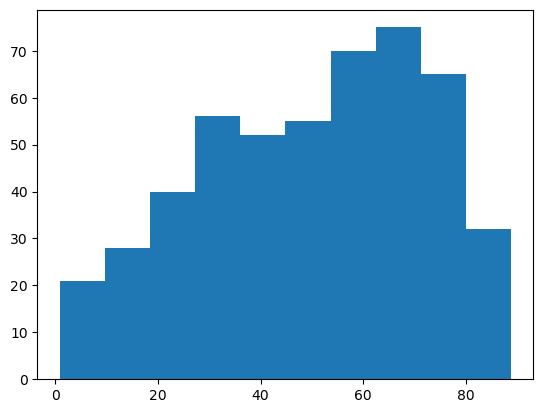

In [65]:
vals = res.vals_mean

plt.figure()
plt.hist(vals)
plt.show()

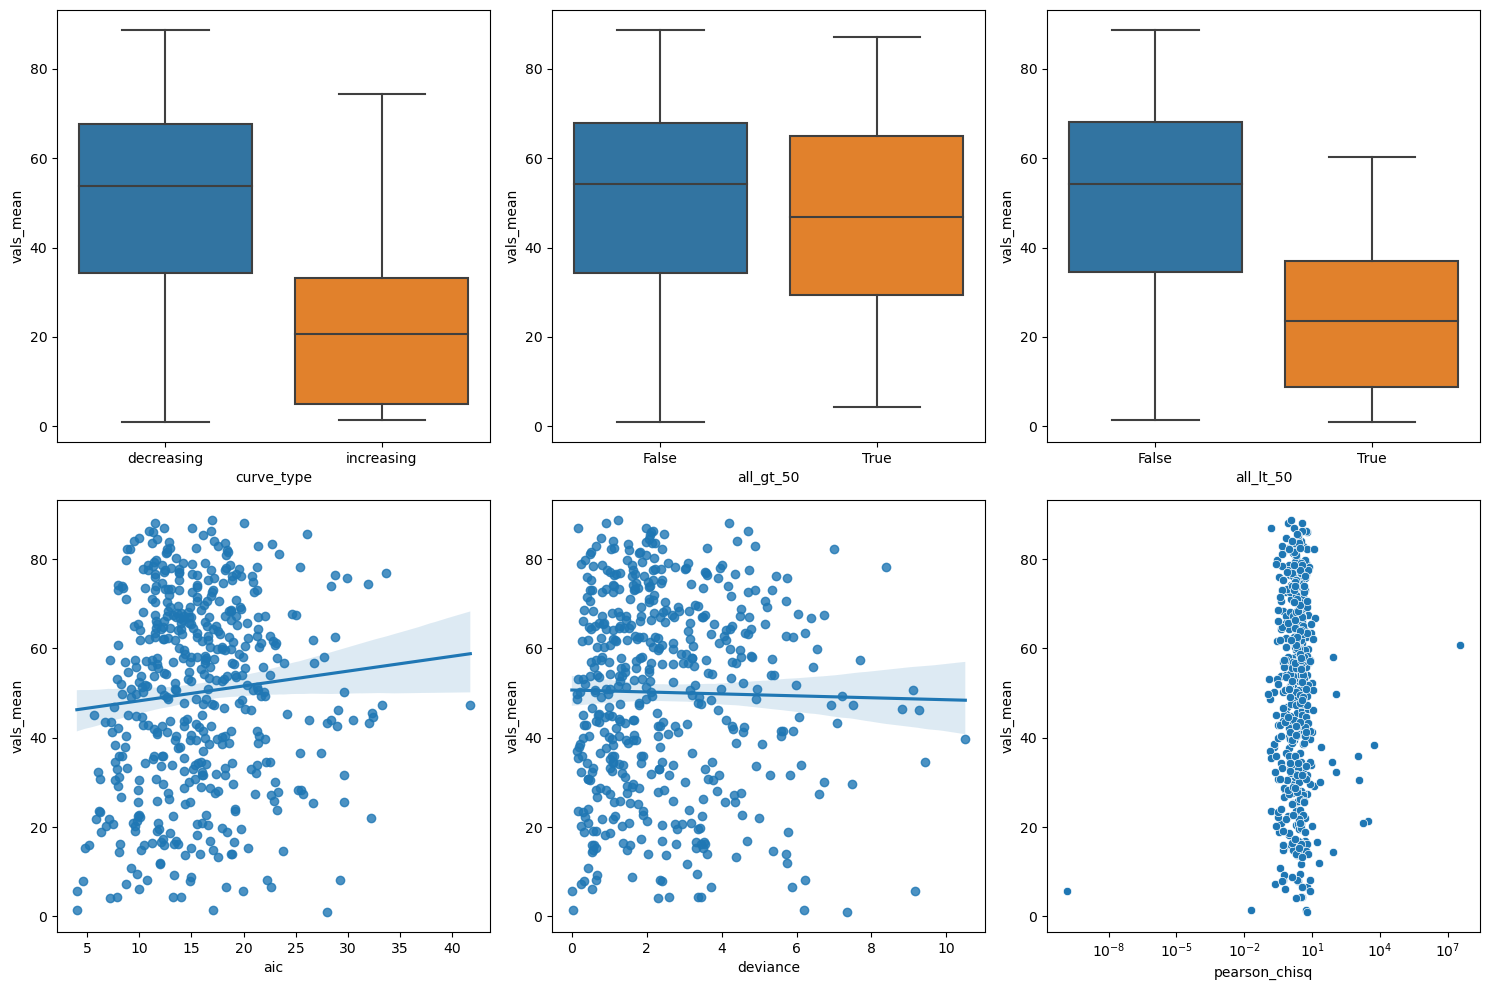

In [66]:
#res = pd.DataFrame({'source_id':source_ids, 'vals':vals, 'inhibitor':'Sorafenib'}).merge(resp[lambda x: (x.inhibitor == 'Sorafenib') & ~x.dbgap_rnaseq_sample.isna()], left_on=['source_id', 'inhibitor'], right_on=['dbgap_rnaseq_sample', 'inhibitor'], how='left', validate='1:1')
res2 = res.merge(resp[lambda x: (x.inhibitor == 'Sorafenib') & ~x.dbgap_rnaseq_sample.isna()], left_on=['source_id'], right_on=['dbgap_rnaseq_sample'], how='left', validate='1:1')

f,axes = plt.subplots(2, 3, figsize=(3*5, 2*5))

sbn.boxplot(x='curve_type', y='vals_mean', data=res2, ax=axes.flat[0])
sbn.boxplot(x='all_gt_50', y='vals_mean', data=res2, ax=axes.flat[1])
sbn.boxplot(x='all_lt_50', y='vals_mean', data=res2, ax=axes.flat[2])
sbn.regplot(x='aic', y='vals_mean', data=res2, ax=axes.flat[3], lowess=False)
sbn.regplot(x='deviance', y='vals_mean', data=res2, ax=axes.flat[4], lowess=False)
sbn.scatterplot(x='pearson_chisq', y='vals_mean', data=res2, ax=axes.flat[5])
axes.flat[5].set_xscale('log')
plt.tight_layout()
plt.show()


In [ ]:
# compare lowest values samples to understand why 
# low expression? weird artifacts? 
# compare to AUC ? all low/high/etc. 

In [67]:
perfs_low = []; perfs_high = [] 

for i in range(10):

    model = NN(in_channels=X.shape[1], 
               out_channels=1, 
               hidden_channels=np.random.randint(5, 100, size=1).item(), 
               num_layers=np.random.choice([1], size=1).item(), 
               norm=np.random.choice([True, False]).item(), 
               dropout=np.random.choice([0, 0.1], size=1).item(), 
               bias=True, 
               act=np.random.choice([torch.nn.Mish, torch.nn.ELU, torch.nn.ReLU], size=1).item())

    X_source, X_test, y_source, y_test, source_ids, test_ids = train_test_split(X, y, ids, test_size=0.1)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    X_source = torch.tensor(X_source, dtype=torch.float32)
    y_source = torch.tensor(y_source, dtype=torch.float32).view(-1, 1)
    y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

    vals = res.set_index('source_id').loc[source_ids].vals_mean.values
    print(len(vals))

    filter_kwargs = {
                    "model"         : model, 
                    "crit"          : torch.nn.MSELoss(),
                    "metric"        : lambda x,y: r2_score(x.ravel(),y.ravel()), # r2_score(x.ravel(),y.ravel()) #lambda x,y: np.mean((x - y)**2)**0.5 , # lambda x,y: r2_score(x,y, multioutput='variance_weighted')
                    "qs"            : np.linspace(0., 0.5, 6), 
                    "batch_size"    : np.random.choice([25, 50, 100, 250, 500], size=1).item(),
                    "lr"            : np.random.choice([1e-2, 1e-3], size=1).item(), 
                    "epochs"        : np.random.choice([50, 100], size=1).item(), 
                    "repl"          : 1,
                    "reset_params"  : True,
                    'return_all_scores' : False
                }

    perf_filter_low, perf_filter_high = get_filtered_scores(x_train       = X_source,
                                                            y_train       = y_source,
                                                            x_test        = X_test,
                                                            y_test        = y_test, 
                                                            vals          = vals, **filter_kwargs)

    perfs_low.append(np.array(perf_filter_low) - perf_filter_low[0])
    perfs_high.append(np.array(perf_filter_high) - perf_filter_high[0])

444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6
444
training filtered models... progress: 5/6


In [68]:
low = np.array(perfs_low)
high = np.array(perfs_high)

In [69]:
# Add random data value comparions on plot below 

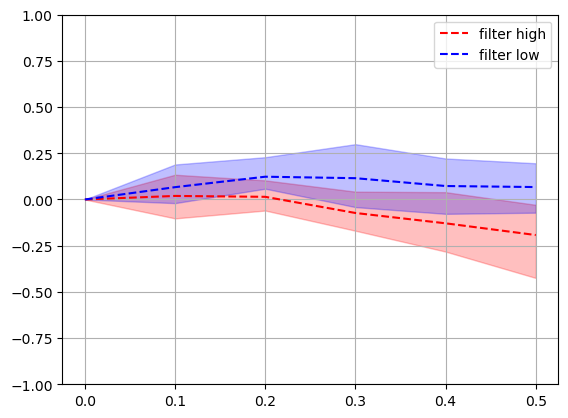

"\nplt.figure()\nplt.plot(filter_kwargs['qs'], [np.mean(x) for x in perf_filter_high], 'r--', label='filter high')\nplt.plot(filter_kwargs['qs'], [np.mean(x) for x in perf_filter_low], 'b--', label='filter low')\nplt.ylim(-1,1)\n\nfor q, h,l in zip(filter_kwargs['qs'], perf_filter_high, perf_filter_low): \n    plt.plot([q]*len(h), h, 'r.')\n    plt.plot([q]*len(l), l, 'b.')\n\nplt.grid()\nplt.legend()\nplt.show()\n"

In [70]:
plt.figure()
plt.plot(filter_kwargs['qs'], high.mean(axis=0), 'r--', label='filter high')
plt.plot(filter_kwargs['qs'], low.mean(axis=0), 'b--', label='filter low')
plt.ylim(-1,1)

plt.fill_between(filter_kwargs['qs'], np.quantile(high, q=0.025, axis=0), np.quantile(high, q=0.975, axis=0), color='r', alpha=0.25)
plt.fill_between(filter_kwargs['qs'], np.quantile(low, q=0.025, axis=0), np.quantile(low, q=0.975, axis=0), color='b', alpha=0.25)

plt.grid()
plt.legend()
plt.show()

'''
plt.figure()
plt.plot(filter_kwargs['qs'], [np.mean(x) for x in perf_filter_high], 'r--', label='filter high')
plt.plot(filter_kwargs['qs'], [np.mean(x) for x in perf_filter_low], 'b--', label='filter low')
plt.ylim(-1,1)

for q, h,l in zip(filter_kwargs['qs'], perf_filter_high, perf_filter_low): 
    plt.plot([q]*len(h), h, 'r.')
    plt.plot([q]*len(l), l, 'b.')

plt.grid()
plt.legend()
plt.show()
'''

In [71]:
pd.DataFrame({'Name':['AnEarlierExperiment', 'MyExperiment01'], 'JobID':[10020210, 10020211], 'ETA':['03:24', None], 'Status':['Running', 'Complete']})

,Name,JobID,ETA,Status
0,AnEarlierExperiment,10020210,03:24,Running
1,MyExperiment01,10020211,None,Complete


In [77]:
dummy = pd.DataFrame({'Gene':['TP53', 'ESR1', '...', 'BRCA'], 'time=0':np.random.rand(4), 'time=1':np.random.rand(4), '...':['...']*4, 'time=T':np.random.rand(4)})
dummy.iloc[2,1] = '...'
dummy.iloc[2,2] = '...'
dummy.iloc[2,4] = '...'
dummy

,Gene,time=0,time=1,...,time=T
0,TP53,0.582337,0.0085,...,0.436919
1,ESR1,0.820172,0.164482,...,0.250932
2,...,...,...,...,...
3,BRCA,0.995359,0.072262,...,0.41804


In [16]:
2**np.logspace(0, 4.5, 250, base=2)

array([2.00000000e+00, 2.01755156e+00, 2.03548133e+00, 2.05379949e+00,
       2.07251654e+00, 2.09164335e+00, 2.11119115e+00, 2.13117151e+00,
       2.15159644e+00, 2.17247830e+00, 2.19382992e+00, 2.21566452e+00,
       2.23799582e+00, 2.26083796e+00, 2.28420562e+00, 2.30811397e+00,
       2.33257869e+00, 2.35761606e+00, 2.38324290e+00, 2.40947663e+00,
       2.43633533e+00, 2.46383769e+00, 2.49200310e+00, 2.52085165e+00,
       2.55040418e+00, 2.58068228e+00, 2.61170835e+00, 2.64350563e+00,
       2.67609824e+00, 2.70951119e+00, 2.74377045e+00, 2.77890300e+00,
       2.81493683e+00, 2.85190103e+00, 2.88982583e+00, 2.92874261e+00,
       2.96868404e+00, 3.00968403e+00, 3.05177787e+00, 3.09500228e+00,
       3.13939544e+00, 3.18499707e+00, 3.23184855e+00, 3.27999293e+00,
       3.32947507e+00, 3.38034166e+00, 3.43264139e+00, 3.48642497e+00,
       3.54174527e+00, 3.59865742e+00, 3.65721894e+00, 3.71748979e+00,
       3.77953258e+00, 3.84341265e+00, 3.90919822e+00, 3.97696052e+00,
      

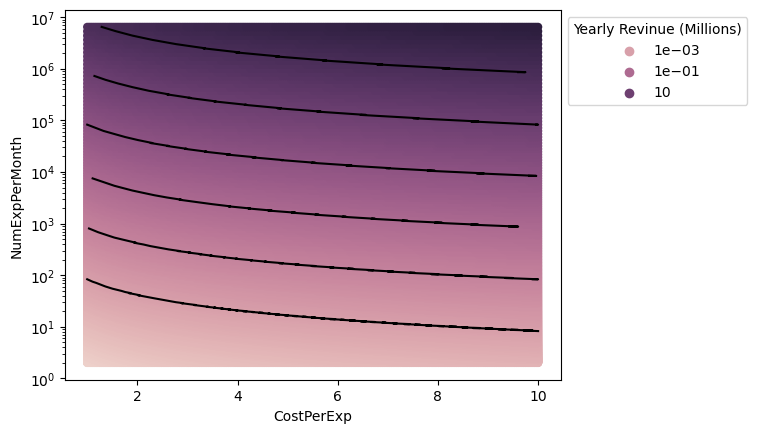

In [27]:
from matplotlib.colors import LogNorm

cost_per_exp = np.linspace(1,10,250)
num_exp_month = 2**np.logspace(0, 4.5, 250, base=2)

cpe,nem = np.meshgrid(cost_per_exp, num_exp_month)
revinue = cpe.ravel()*nem.ravel()*12 

res = pd.DataFrame({'CostPerExp':cpe.ravel(), 'NumExpPerMonth':nem.ravel(), 'Yearly Revinue (Millions)':(revinue.ravel()/1e6)})

plt.figure()
ax = sbn.scatterplot(x='CostPerExp', y='NumExpPerMonth', hue='Yearly Revinue (Millions)', data=res, linewidth=0, hue_norm=LogNorm())
sbn.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

for val in [1e3, 1e4, 1e5, 1e6, 1e7, 1e8]: 
    contour_idx = np.isclose(revinue, val, rtol=0.01).nonzero()[0]
    plt.plot(cpe.ravel()[contour_idx], nem.ravel()[contour_idx], 'k')

plt.yscale('log')
plt.show()

In [31]:
f'{revinue.max():.3E}'

'7.775E+08'

In [100]:
contour_idx

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [96]:
revinue

array([1.20000000e+02, 1.30909091e+02, 1.41818182e+02, ...,
       1.17818182e+08, 1.18909091e+08, 1.20000000e+08])